In [1]:
from datasets import load_dataset

dataset = load_dataset('stanfordnlp/imdb')
train = dataset['train'].to_pandas()
test = dataset['test'].to_pandas()
unsupervised = dataset['unsupervised'].to_pandas()

c:\Users\filipondios\Desktop\IMDbXAI\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import html
import re

def preprocess_medium(text: str) -> str:
    """ medium preprocessing for neural networks """
    # remove HTML and keep useful punctuation (!?)
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def preprocess_light(text: str) -> str:
    """ light preprocessing for neural networks """
    # remove HTML and keep useful punctuation (!?)
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r"[^a-zA-Z0-9\s.,!?']", ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

In [3]:
print('Original:', train['text'][0], end='\n\n')
print('Medium:', preprocess_medium(train['text'][0]), end='\n\n')
print('Light:', preprocess_light(train['text'][0]))

Original: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [4]:
from joblib import Parallel, delayed

def parallel_apply(series, f):
    # applies a function to a pandas series in parallel
    return Parallel(n_jobs=-1, backend='threading')(delayed(f)(x) for x in series)

In [5]:
train['text_medium'] = parallel_apply(train['text'], preprocess_medium)
train['text_light'] = parallel_apply(train['text'], preprocess_light)

In [6]:
test['text_medium'] = parallel_apply(test['text'], preprocess_medium)
test['text_light'] = parallel_apply(test['text'], preprocess_light)

## Embeddings

In [41]:
from keras.callbacks import EarlyStopping

batch_size = 32
epochs = 10
validation_split = 0.2
verbose = 2
callback = [EarlyStopping(monitor='val_loss',
    patience=2, restore_best_weights=True)]
emb_dim = 128
max_len = 512
seed = 42

In [8]:
import random
import tensorflow as tf
import numpy as np

random.seed(seed)
tf.random.set_seed(seed)
np.random.seed(seed)

In [9]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

def plot_history(history):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training Accuracy')
    plt.plot(x, val_acc, 'r', label='Validation Accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()


In [10]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def predict(model, x_test_pad, y_test_categorical):
    y_pred_probs = model.predict(x_test_pad)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_categorical, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    plt.xlabel('Prediction')
    plt.ylabel('Real')
    plt.title('Confusion Matrix')
    plt.show()
    print(classification_report(y_true, y_pred, 
        target_names=['Negative', 'Positive']))

In [11]:
# get the train axes (x,y) = (text,label)
x_train = train['text_light']
y_train = train['label']

# get the test axes (x,y) = (text,label)
x_test = test['text_light']
y_test = test['label']

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(x_train)
vocab_size = len(tokenizer.word_index) + 1
x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

In [42]:
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical

x_train_pad = pad_sequences(x_train_seq, maxlen=max_len, padding='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_len, padding='post')

y_train_categorical = to_categorical(y_train, num_classes=2)
y_test_categorical = to_categorical(y_test, num_classes=2)

In [14]:
from keras.models import Sequential
from keras.layers import Embedding, Dense, GlobalAveragePooling1D

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=emb_dim),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
model.build(input_shape=(None, x_train_pad.shape[1]))

Epoch 1/10
625/625 - 81s - 130ms/step - acc: 0.6915 - loss: 0.5724 - val_acc: 0.6822 - val_loss: 0.6201
Epoch 2/10
625/625 - 81s - 129ms/step - acc: 0.8508 - loss: 0.3442 - val_acc: 0.8972 - val_loss: 0.3102
Epoch 3/10
625/625 - 81s - 129ms/step - acc: 0.8803 - loss: 0.2857 - val_acc: 0.6660 - val_loss: 0.6765
Epoch 4/10
625/625 - 81s - 129ms/step - acc: 0.9054 - loss: 0.2350 - val_acc: 0.3736 - val_loss: 1.4314


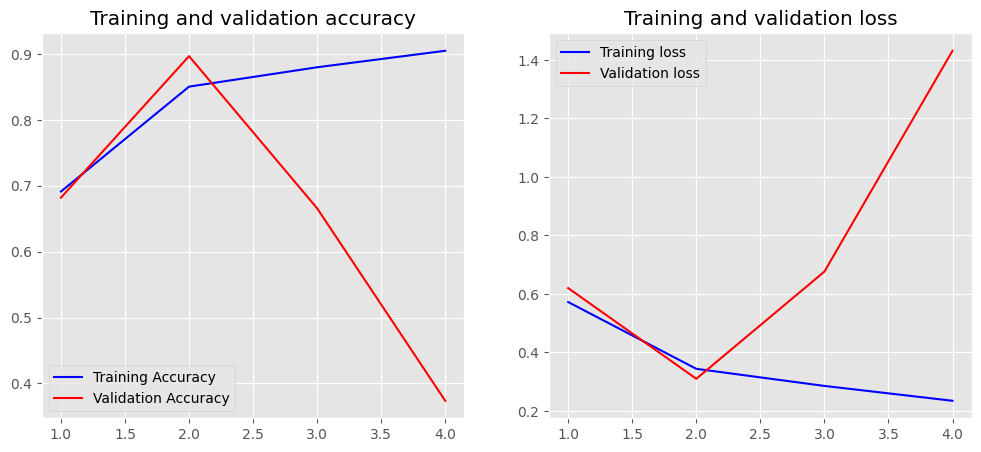

In [15]:
history = model.fit(x_train_pad, y_train_categorical, epochs=epochs, batch_size=batch_size,
    validation_split=validation_split, verbose=verbose, callbacks=callback)
plot_history(history)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 696us/step


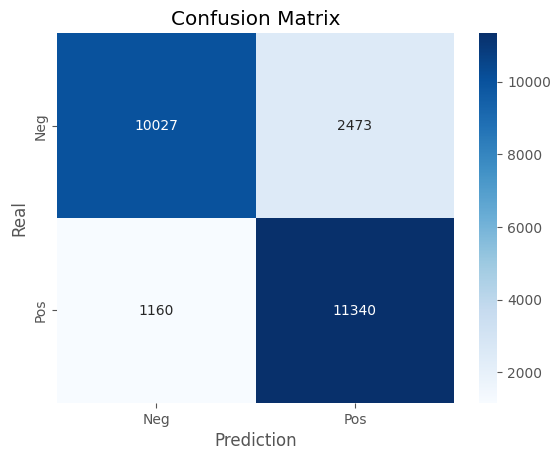

              precision    recall  f1-score   support

    Negative       0.90      0.80      0.85     12500
    Positive       0.82      0.91      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.86      0.85      0.85     25000
weighted avg       0.86      0.85      0.85     25000

Accuracy: 0.8547


In [16]:
predict(model, x_test_pad, y_test_categorical)
_, acc = model.evaluate(x_test_pad, y_test_categorical, verbose=0)
print(f"Accuracy: {acc:.4f}")

In [17]:
from keras.layers import Dropout

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=emb_dim),
    GlobalAveragePooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
model.build(input_shape=(None, x_train_pad.shape[1]))

Epoch 1/10
625/625 - 80s - 128ms/step - acc: 0.6433 - loss: 0.6348 - val_acc: 0.3418 - val_loss: 0.8347
Epoch 2/10
625/625 - 80s - 127ms/step - acc: 0.7869 - loss: 0.4470 - val_acc: 0.7112 - val_loss: 0.5941


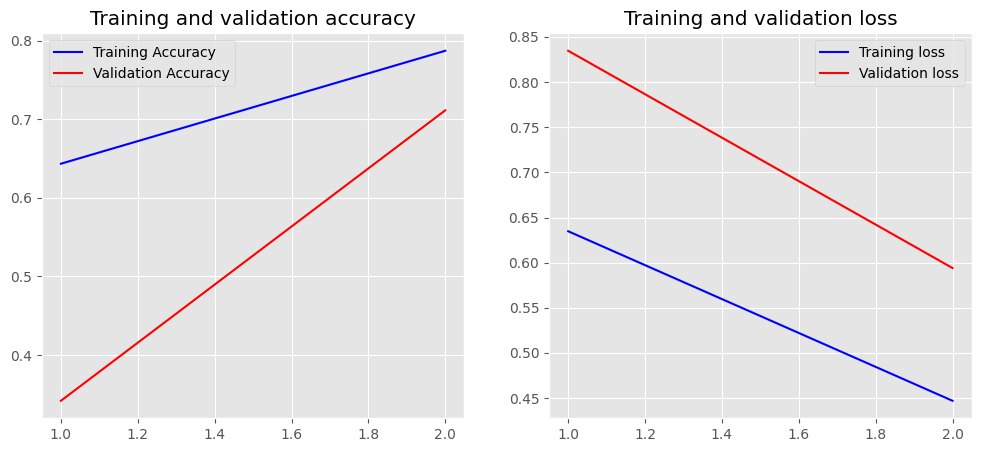

In [18]:
history = model.fit(x_train_pad, y_train_categorical, epochs=epochs, batch_size=batch_size,
    validation_split=validation_split, verbose=verbose, callbacks=callback)
plot_history(history)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 619us/step


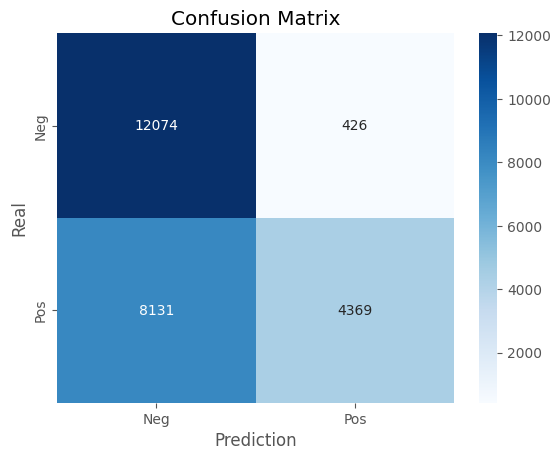

              precision    recall  f1-score   support

    Negative       0.60      0.97      0.74     12500
    Positive       0.91      0.35      0.51     12500

    accuracy                           0.66     25000
   macro avg       0.75      0.66      0.62     25000
weighted avg       0.75      0.66      0.62     25000

Accuracy: 0.6577


In [19]:
predict(model, x_test_pad, y_test_categorical)
_, acc = model.evaluate(x_test_pad, y_test_categorical, verbose=0)
print(f"Accuracy: {acc:.4f}")

In [22]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=emb_dim),
    GlobalAveragePooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
model.build(input_shape=(None, x_train_pad.shape[1]))

Epoch 1/10
625/625 - 82s - 131ms/step - acc: 0.5852 - loss: 0.6640 - val_acc: 0.7906 - val_loss: 0.5515
Epoch 2/10
625/625 - 82s - 131ms/step - acc: 0.7697 - loss: 0.4745 - val_acc: 0.8238 - val_loss: 0.3836
Epoch 3/10
625/625 - 81s - 129ms/step - acc: 0.8460 - loss: 0.3511 - val_acc: 0.8796 - val_loss: 0.3091
Epoch 4/10
625/625 - 80s - 129ms/step - acc: 0.8754 - loss: 0.2976 - val_acc: 0.8762 - val_loss: 0.3105
Epoch 5/10
625/625 - 80s - 129ms/step - acc: 0.8921 - loss: 0.2617 - val_acc: 0.8834 - val_loss: 0.3083
Epoch 6/10
625/625 - 81s - 129ms/step - acc: 0.9035 - loss: 0.2372 - val_acc: 0.8918 - val_loss: 0.2837
Epoch 7/10
625/625 - 82s - 131ms/step - acc: 0.9159 - loss: 0.2099 - val_acc: 0.8834 - val_loss: 0.2951
Epoch 8/10
625/625 - 83s - 133ms/step - acc: 0.9248 - loss: 0.1924 - val_acc: 0.8868 - val_loss: 0.2969
Epoch 9/10
625/625 - 82s - 131ms/step - acc: 0.9313 - loss: 0.1781 - val_acc: 0.8554 - val_loss: 0.3650


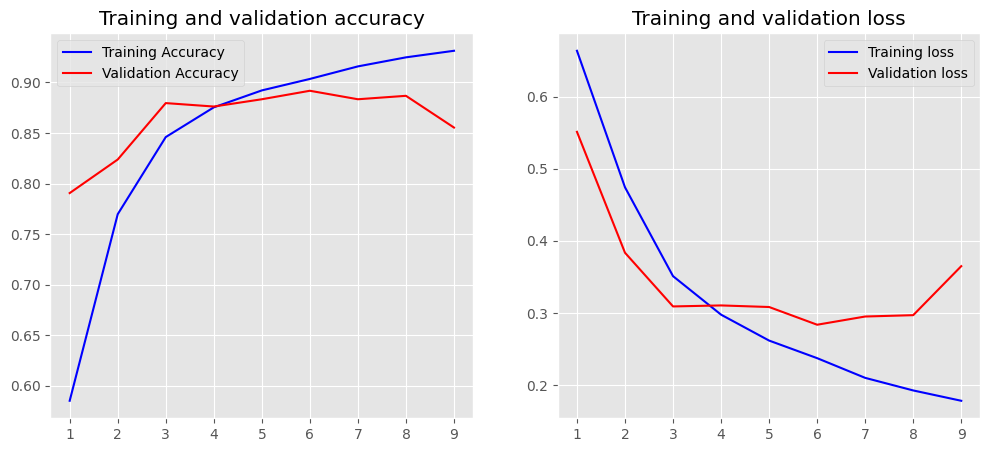

In [ ]:
from sklearn.model_selection import train_test_split

x_tr, x_val, y_tr, y_val = train_test_split(x_train_pad, y_train_categorical,
    test_size=0.2, random_state=seed, stratify=y_train)

history = model.fit(x_tr, y_tr, epochs=epochs, batch_size=batch_size,
    validation_data=(x_val, y_val), verbose=verbose, 
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])
plot_history(history)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 645us/step


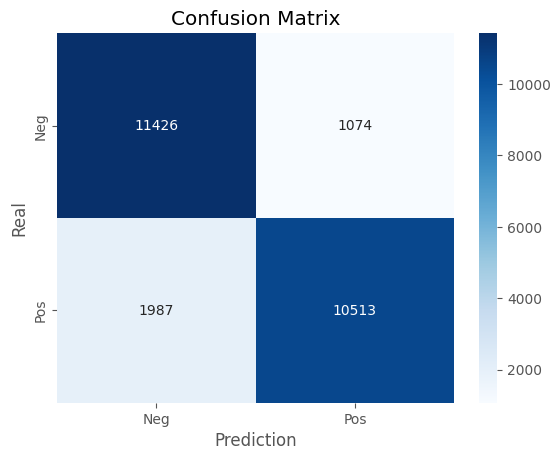

              precision    recall  f1-score   support

    Negative       0.85      0.91      0.88     12500
    Positive       0.91      0.84      0.87     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000

Accuracy: 0.8776


In [24]:
predict(model, x_test_pad, y_test_categorical)
_, acc = model.evaluate(x_test_pad, y_test_categorical, verbose=0)
print(f"Accuracy: {acc:.4f}")

In [25]:
from keras.regularizers import l2

emb_dim = 64
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=emb_dim),
    GlobalAveragePooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(2, activation='softmax')])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
model.build(input_shape=(None, x_train_pad.shape[1]))

Epoch 1/10
625/625 - 38s - 60ms/step - acc: 0.5638 - loss: 0.6939 - val_acc: 0.5866 - val_loss: 0.6510
Epoch 2/10
625/625 - 38s - 60ms/step - acc: 0.7537 - loss: 0.5232 - val_acc: 0.7430 - val_loss: 0.4990
Epoch 3/10
625/625 - 37s - 60ms/step - acc: 0.8432 - loss: 0.3868 - val_acc: 0.8122 - val_loss: 0.4122
Epoch 4/10
625/625 - 37s - 59ms/step - acc: 0.8771 - loss: 0.3236 - val_acc: 0.8738 - val_loss: 0.3370
Epoch 5/10
625/625 - 37s - 60ms/step - acc: 0.8911 - loss: 0.2913 - val_acc: 0.8334 - val_loss: 0.3841
Epoch 6/10
625/625 - 37s - 59ms/step - acc: 0.9060 - loss: 0.2590 - val_acc: 0.8498 - val_loss: 0.3632
Epoch 7/10
625/625 - 37s - 59ms/step - acc: 0.9181 - loss: 0.2348 - val_acc: 0.8948 - val_loss: 0.2958
Epoch 8/10
625/625 - 37s - 59ms/step - acc: 0.9261 - loss: 0.2174 - val_acc: 0.8948 - val_loss: 0.2978
Epoch 9/10
625/625 - 37s - 59ms/step - acc: 0.9317 - loss: 0.2006 - val_acc: 0.8622 - val_loss: 0.3542
Epoch 10/10
625/625 - 37s - 59ms/step - acc: 0.9355 - loss: 0.1896 - val_

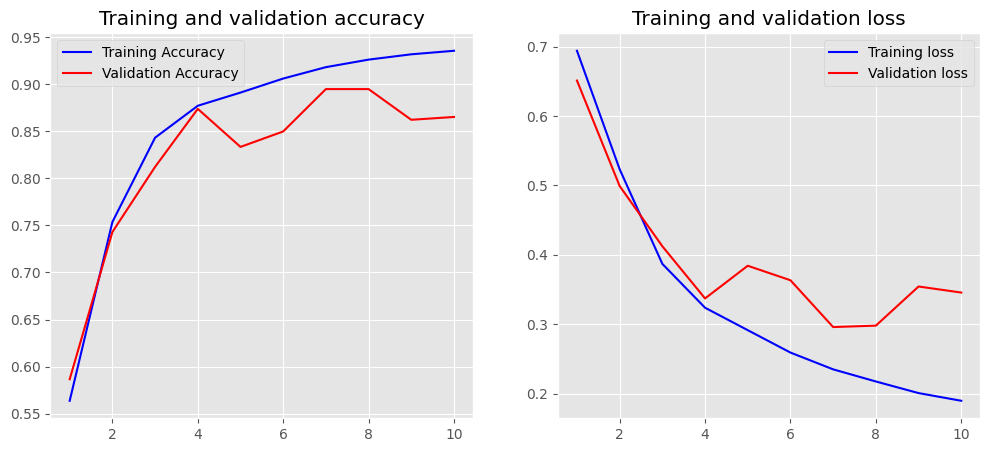

In [ ]:
history = model.fit(x_tr, y_tr, epochs=epochs, batch_size=batch_size,
    validation_data=(x_val, y_val), verbose=verbose, 
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])
plot_history(history)

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step


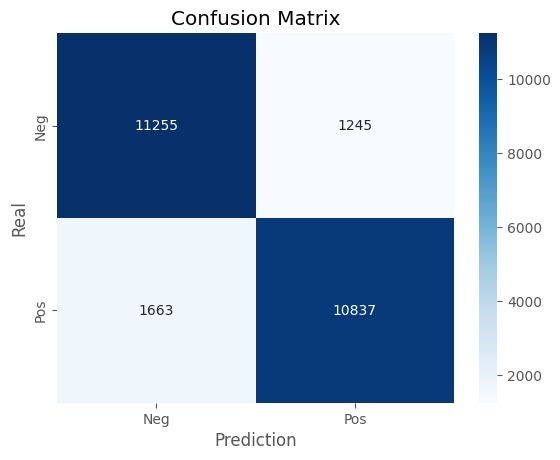

              precision    recall  f1-score   support

    Negative       0.87      0.90      0.89     12500
    Positive       0.90      0.87      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000

Accuracy: 0.8837


In [27]:
predict(model, x_test_pad, y_test_categorical)
_, acc = model.evaluate(x_test_pad, y_test_categorical, verbose=0)
print(f"Accuracy: {acc:.4f}")

### Embeddings con LSTM

In [54]:
max_len = 200
x_train_pad = pad_sequences(x_train_seq, maxlen=max_len, padding='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_len, padding='post')

In [55]:
from keras.layers import LSTM

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=emb_dim),
    LSTM(64),
    Dropout(0.4),
    Dense(2, activation='softmax')])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
model.build(input_shape=(None, x_train_pad.shape[1]))

Epoch 1/30
625/625 - 52s - 82ms/step - acc: 0.5789 - loss: 0.6696 - val_acc: 0.6860 - val_loss: 0.6097
Epoch 2/30
625/625 - 51s - 81ms/step - acc: 0.6249 - loss: 0.6076 - val_acc: 0.6712 - val_loss: 0.5714
Epoch 3/30
625/625 - 51s - 81ms/step - acc: 0.7703 - loss: 0.4873 - val_acc: 0.8196 - val_loss: 0.4659
Epoch 4/30
625/625 - 50s - 81ms/step - acc: 0.8759 - loss: 0.3266 - val_acc: 0.8610 - val_loss: 0.3471
Epoch 5/30
625/625 - 50s - 81ms/step - acc: 0.9439 - loss: 0.1704 - val_acc: 0.8754 - val_loss: 0.3522
Epoch 6/30
625/625 - 50s - 81ms/step - acc: 0.9714 - loss: 0.0986 - val_acc: 0.8696 - val_loss: 0.3960
Epoch 7/30
625/625 - 51s - 81ms/step - acc: 0.9855 - loss: 0.0576 - val_acc: 0.8716 - val_loss: 0.4464


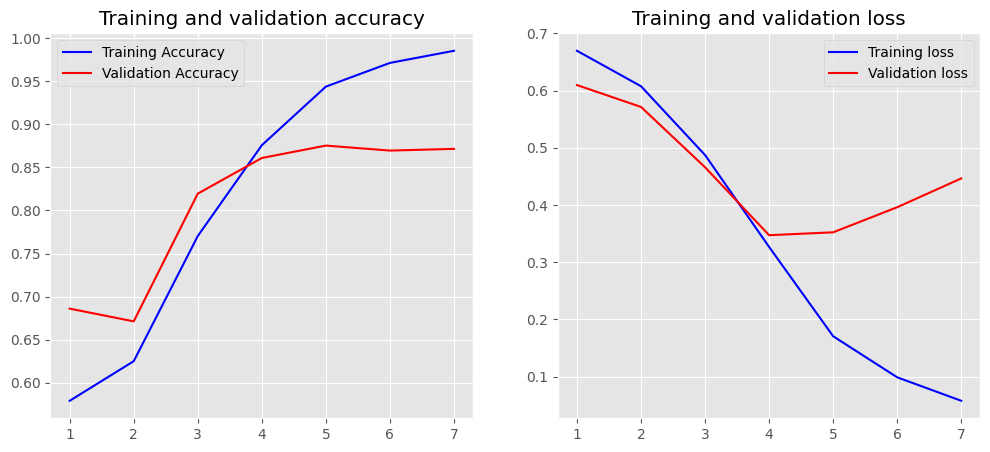

In [56]:
x_tr, x_val, y_tr, y_val = train_test_split(x_train_pad, y_train_categorical,
    test_size=0.2, random_state=seed, stratify=y_train)

history = model.fit(x_tr, y_tr, epochs=epochs, batch_size=batch_size,
    validation_data=(x_val, y_val), verbose=verbose,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])
plot_history(history)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step


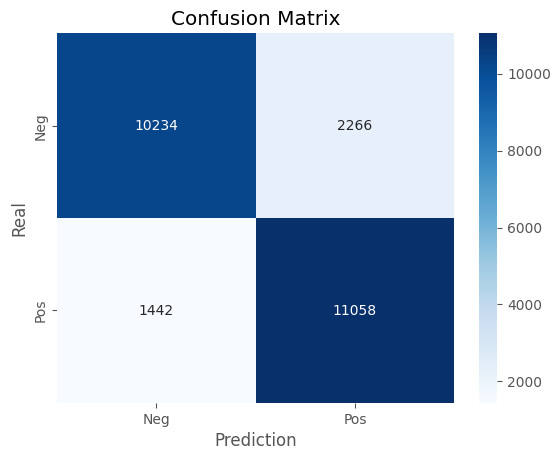

              precision    recall  f1-score   support

    Negative       0.88      0.82      0.85     12500
    Positive       0.83      0.88      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000

Accuracy: 0.8517


In [57]:
predict(model, x_test_pad, y_test_categorical)
_, acc = model.evaluate(x_test_pad, y_test_categorical, verbose=0)
print(f"Accuracy: {acc:.4f}")

In [58]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=emb_dim),
    LSTM(64, recurrent_dropout=0.3),
    Dropout(0.4),
    Dense(2, activation='softmax')])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
model.build(input_shape=(None, x_train_pad.shape[1]))

Epoch 1/30
625/625 - 61s - 98ms/step - acc: 0.5981 - loss: 0.6555 - val_acc: 0.7174 - val_loss: 0.5743
Epoch 2/30
625/625 - 57s - 92ms/step - acc: 0.6902 - loss: 0.5661 - val_acc: 0.5946 - val_loss: 0.6417
Epoch 3/30
625/625 - 57s - 92ms/step - acc: 0.7477 - loss: 0.4983 - val_acc: 0.7936 - val_loss: 0.5046
Epoch 4/30
625/625 - 57s - 91ms/step - acc: 0.8479 - loss: 0.3960 - val_acc: 0.7888 - val_loss: 0.5210
Epoch 5/30
625/625 - 57s - 91ms/step - acc: 0.8662 - loss: 0.3499 - val_acc: 0.7898 - val_loss: 0.5301
Epoch 6/30
625/625 - 57s - 91ms/step - acc: 0.8809 - loss: 0.3276 - val_acc: 0.7960 - val_loss: 0.5344


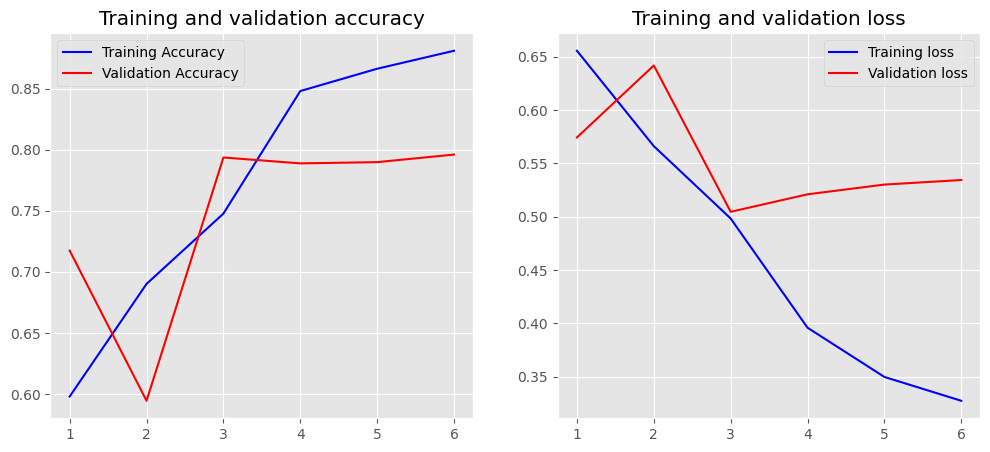

In [59]:
history = model.fit(x_tr, y_tr, epochs=epochs, batch_size=batch_size,
    validation_data=(x_val, y_val), verbose=verbose,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])
plot_history(history)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


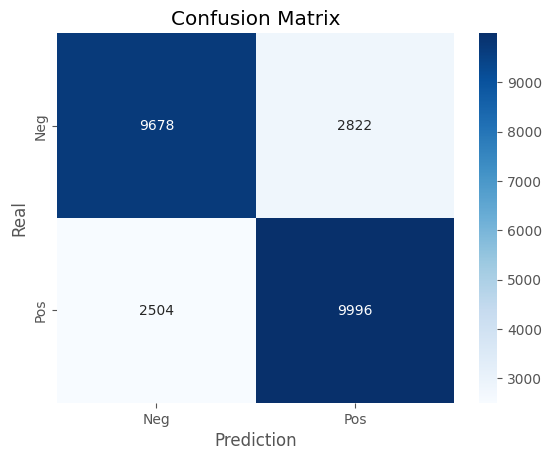

              precision    recall  f1-score   support

    Negative       0.79      0.77      0.78     12500
    Positive       0.78      0.80      0.79     12500

    accuracy                           0.79     25000
   macro avg       0.79      0.79      0.79     25000
weighted avg       0.79      0.79      0.79     25000

Accuracy: 0.7870


In [60]:
predict(model, x_test_pad, y_test_categorical)
_, acc = model.evaluate(x_test_pad, y_test_categorical, verbose=0)
print(f"Accuracy: {acc:.4f}")

In [61]:
from keras.layers import Bidirectional
from keras.optimizers import Adam

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=emb_dim),
    Bidirectional(LSTM(64, recurrent_dropout=0.3)),
    Dropout(0.4),
    Dense(2, activation='softmax')])
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0005), metrics=['acc'])
model.build(input_shape=(None, x_train_pad.shape[1]))

Epoch 1/30
625/625 - 85s - 135ms/step - acc: 0.6824 - loss: 0.6005 - val_acc: 0.7862 - val_loss: 0.4681
Epoch 2/30
625/625 - 82s - 131ms/step - acc: 0.8401 - loss: 0.3961 - val_acc: 0.8424 - val_loss: 0.3822
Epoch 3/30
625/625 - 82s - 131ms/step - acc: 0.8579 - loss: 0.3391 - val_acc: 0.8308 - val_loss: 0.4159
Epoch 4/30
625/625 - 83s - 132ms/step - acc: 0.9014 - loss: 0.2583 - val_acc: 0.7574 - val_loss: 0.5996
Epoch 5/30
625/625 - 82s - 131ms/step - acc: 0.9272 - loss: 0.2046 - val_acc: 0.8494 - val_loss: 0.4023


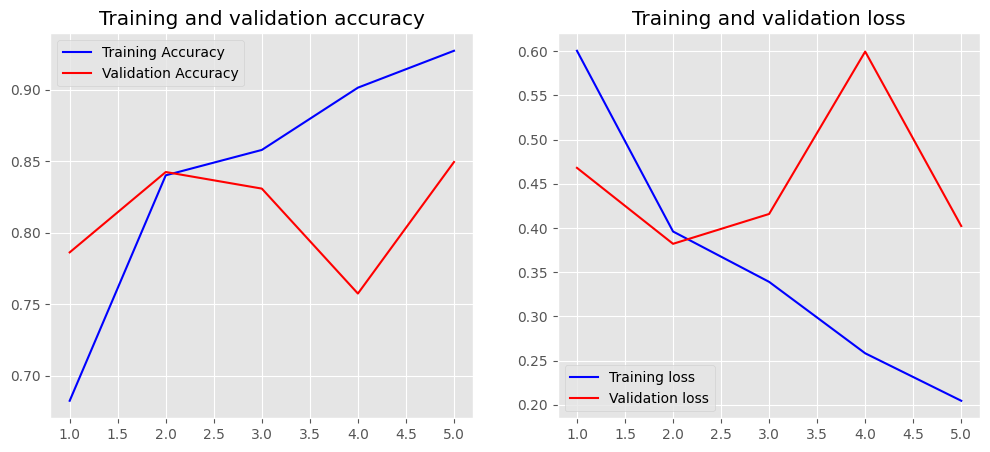

In [62]:
history = model.fit(x_tr, y_tr, epochs=epochs, batch_size=batch_size,
    validation_data=(x_val, y_val), verbose=verbose,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])
plot_history(history)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step


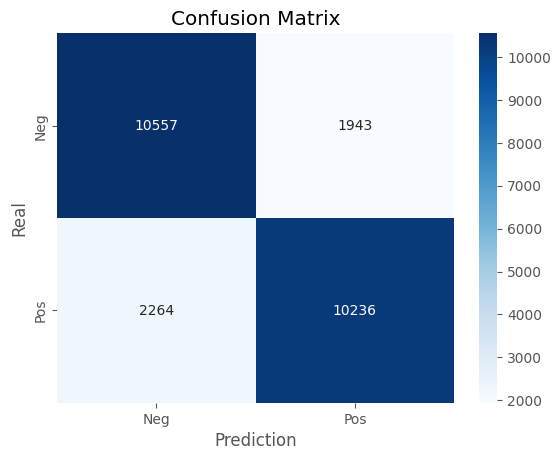

              precision    recall  f1-score   support

    Negative       0.82      0.84      0.83     12500
    Positive       0.84      0.82      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000

Accuracy: 0.8317


In [63]:
predict(model, x_test_pad, y_test_categorical)
_, acc = model.evaluate(x_test_pad, y_test_categorical, verbose=0)
print(f"Accuracy: {acc:.4f}")